In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [3]:
df = pd.read_csv("Case Study A.csv")  # make sure file is in same folder

In [4]:
print(df.head())
print(df.info())
print(df.isnull().sum())

      Age Attrition BusinessTravel DailyRate              Department  \
0    Yes         No            NaN       NaN  Research & Development   
1    30.0       NaN  Travel_Rarely     330.0         Human Resources   
2     NaN       NaN            NaN       NaN                     NaN   
3     NaN       NaN            NaN       NaN                     NaN   
4  2400.0       Yes  Travel_Rarely   59920.0                   Sales   

  DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0              1.0        2.0        Medical            NaN          1994.0   
1              1.0        3.0  Life Sciences            NaN          1499.0   
2              NaN        NaN            NaN            NaN             NaN   
3              NaN        NaN            NaN            NaN             NaN   
4           1160.0        4.0  Life Sciences            NaN            27.0   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...                  

In [6]:
# Fill numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns (FIXED)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.842809364548495
Precision: 1.0
Recall: 0.0784313725490196
F1 Score: 0.14545454545454545

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91       248
           1       1.00      0.08      0.15        51

    accuracy                           0.84       299
   macro avg       0.92      0.54      0.53       299
weighted avg       0.87      0.84      0.78       299



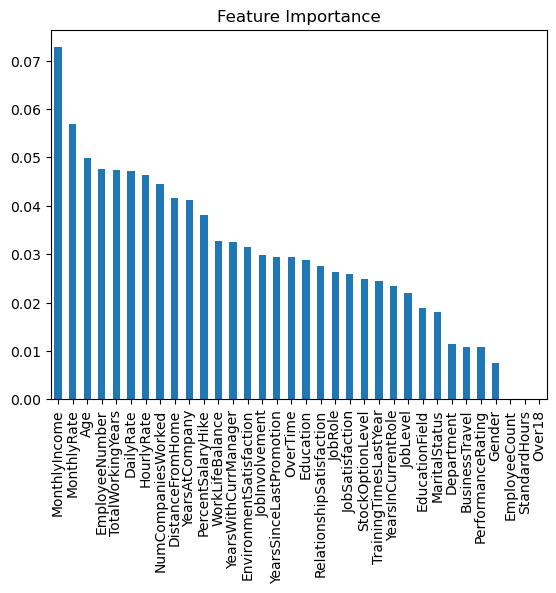

In [16]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure()
feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

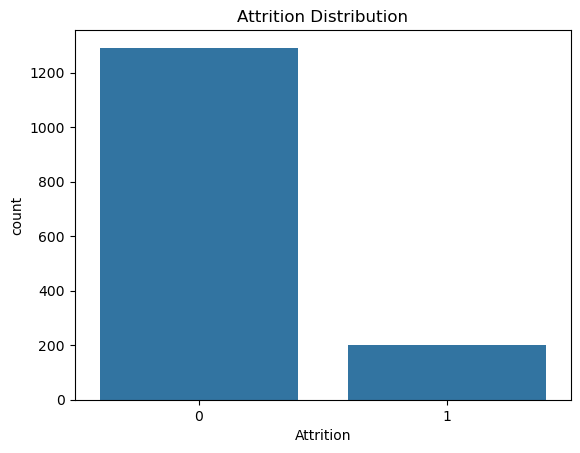

In [17]:
sns.countplot(x=y)
plt.title("Attrition Distribution")
plt.show()